In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [19]:
import os
import json
import pandas as pd

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    # extract the number after the second underscore
    key=lambda x: int(x.split('_')[2])
)

# 2) Collect metrics into a list of dicts
records = []
for d in dirs:
    metrics_path = os.path.join(d, 'performance_metrics.json')
    if not os.path.exists(metrics_path):
        print(f"Warning: no metrics in {d}, skipping")
        continue

    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    # parse out N
    N = int(d.split('_')[2])
    rec = {'N_removed': N}

    # flatten output_1 and output_2 metrics
    for output in ['output_1', 'output_2']:
        for m in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
            rec[f"{output}_{m}"] = metrics.get(output, {}).get(m, None)

    records.append(rec)

# 3) Build and sort DataFrame
df = pd.DataFrame(records)
df = df.sort_values('N_removed').reset_index(drop=True)
df['N_sensors'] = df['N_removed'].iloc[::-1].values
df

,N_removed,output_1_r2,output_1_mae,output_1_mape,output_1_rmse,output_1_rmspe,output_2_r2,output_2_mae,output_2_mape,output_2_rmse,output_2_rmspe,N_sensors
0,1,0.997216,5.299678,2.767654,9.754327,7.510534,0.993971,9.224387,8.212802,11.731440,14.770368,61
1,2,0.997383,4.817566,2.528564,9.456797,7.308458,0.994489,7.762845,6.753383,11.215842,14.223900,60
2,3,0.996519,5.898714,3.167326,10.907664,7.592963,0.973216,23.004793,27.463645,24.726120,39.381254,59
3,4,0.997127,4.729129,2.687778,9.909077,7.978787,0.996814,5.010219,4.494914,8.528180,13.149172,58
4,5,0.997286,3.030881,1.726292,9.631652,7.361066,0.997616,3.637866,5.112357,7.376698,15.183836,57
...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,0.577809,91.114464,54.458523,120.122498,83.403182,-0.187711,104.065674,54.054421,164.653214,62.334132,5
57,58,0.192821,135.328461,82.027048,166.094269,121.459484,-0.448799,115.355537,51.683331,181.852356,56.764126,4
58,59,-0.047877,158.586395,100.657642,189.245239,147.200966,-0.665513,125.785568,54.079396,194.979446,61.694777,3
59,60,0.064380,136.743881,73.777217,178.821442,106.158149,-0.730052,130.474289,57.608187,198.721298,64.721555,2


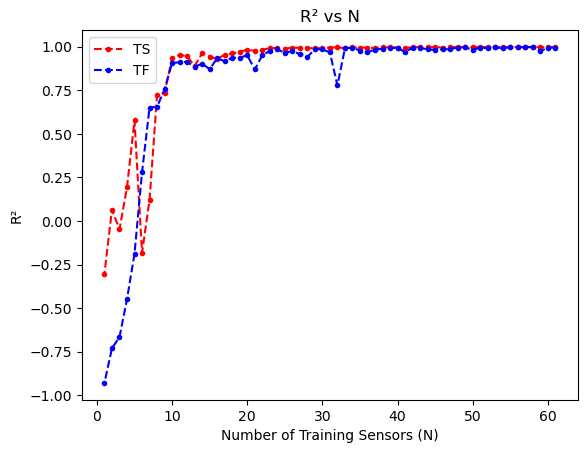

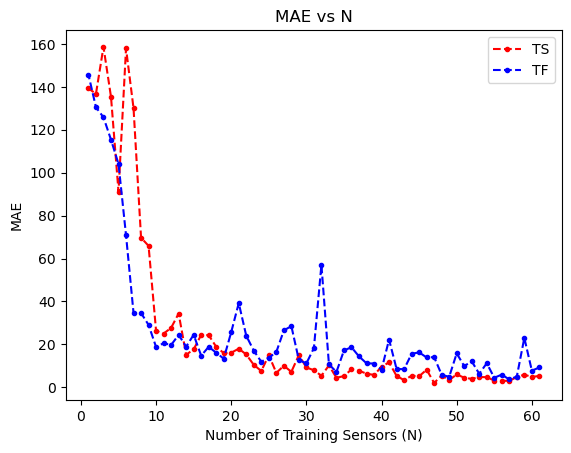

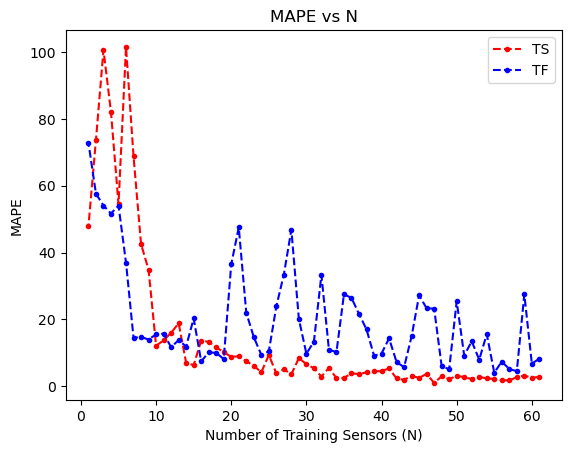

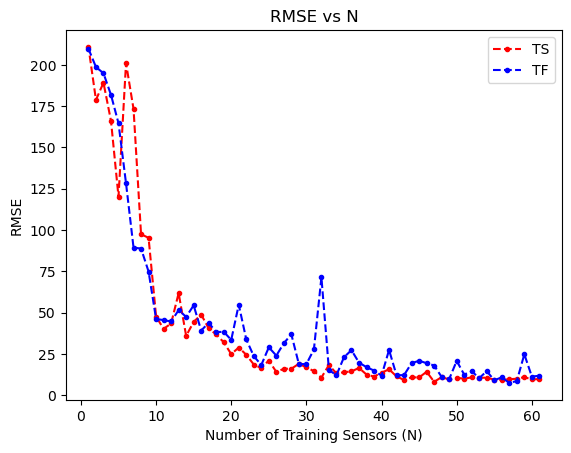

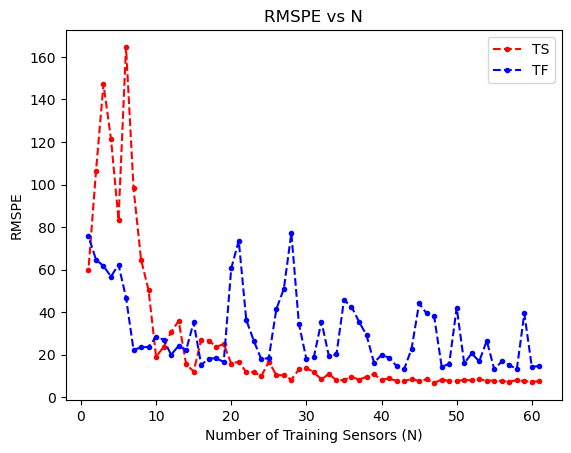

In [21]:
# Plot each metric vs. N
for metric in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
    plt.figure()
    plt.plot(df['N_sensors'], df[f'output_1_{metric}'], '--o', color='r',label='TS', markersize=3)
    plt.plot(df['N_sensors'], df[f'output_2_{metric}'], '--o', color='b',label='TF',  markersize=3)
    plt.xlabel('Number of Training Sensors (N)')
    ylabel = 'R\u00b2' if metric == 'r2' else metric.upper()
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs N")
    plt.legend()
    plt.show()

C:\Users\Logan\AppData\Local\Temp\ipykernel_8072\2854600294.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', len(sampled))


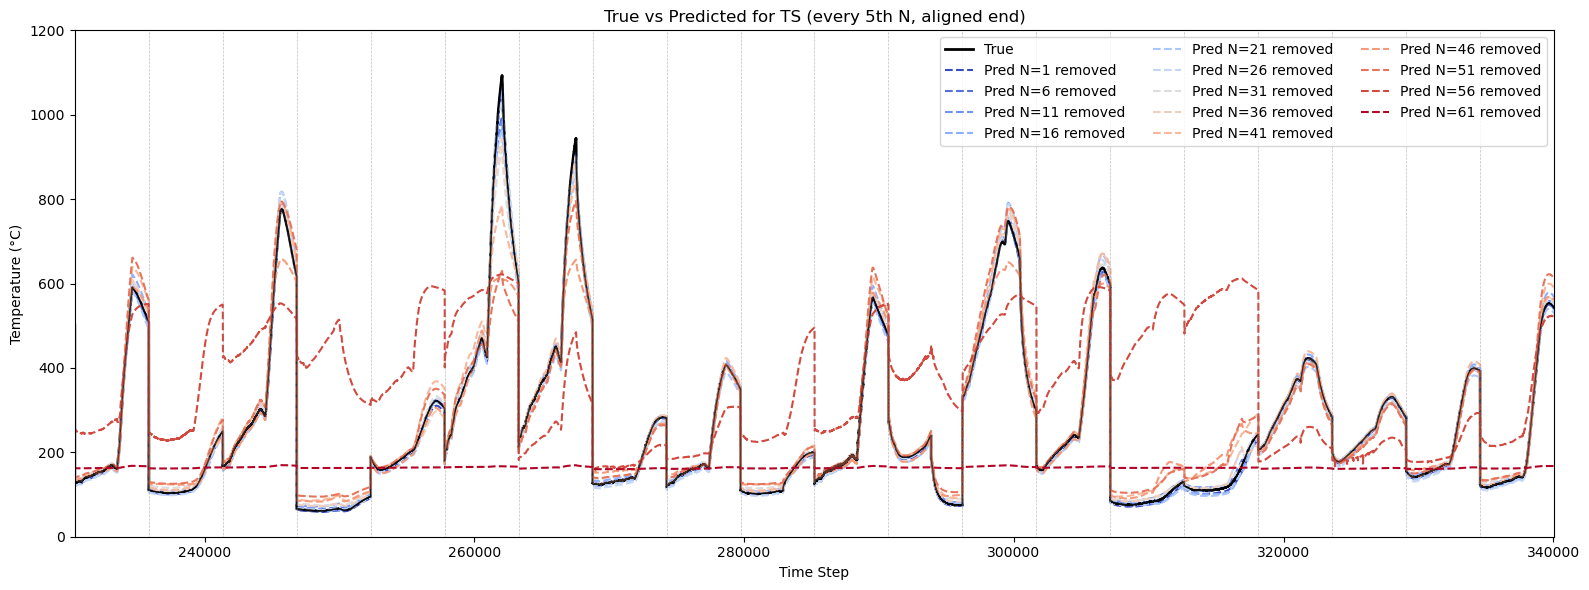

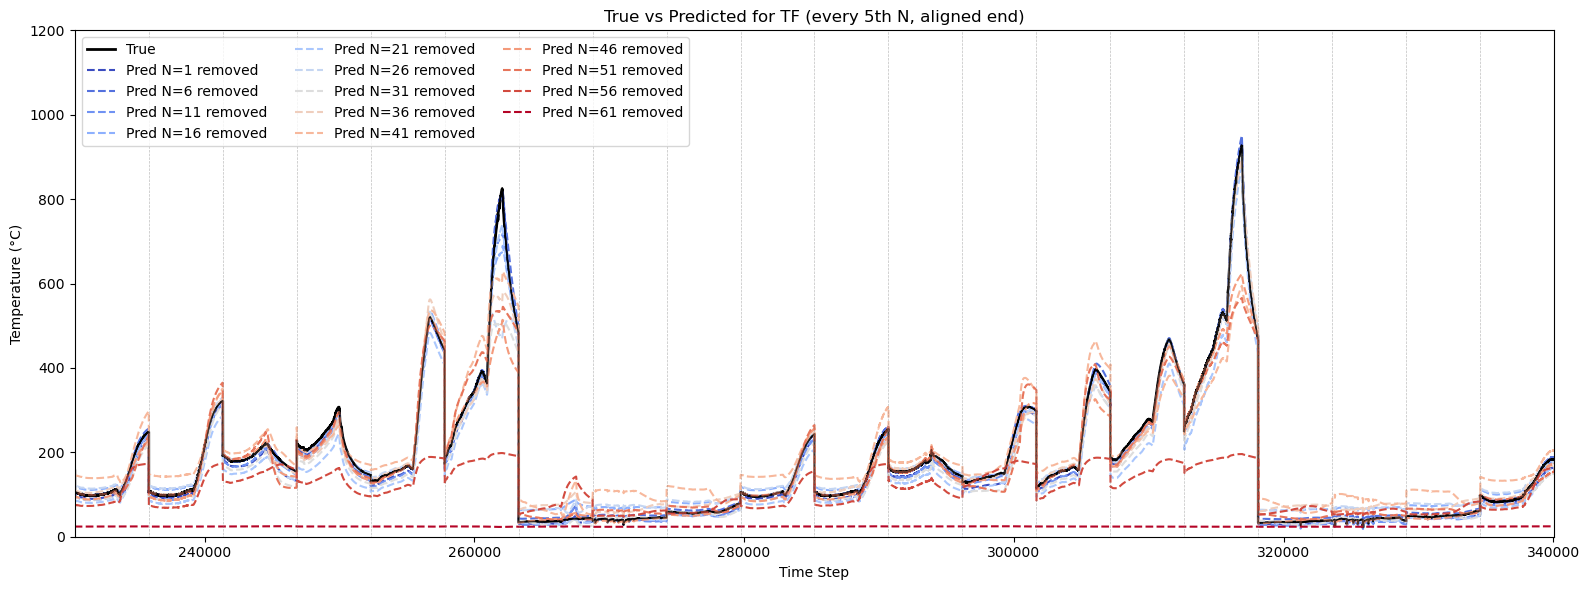

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    # extract the number after the second underscore
    key=lambda x: int(x.split('_')[2])
)

# Load all runs
runs = []
for d in dirs:
    N = int(d.split('_')[2])
    tfile = os.path.join(d, 'Ytrue_rescaled.npy')
    pfile = os.path.join(d, 'Ypred_rescaled.npy')
    if os.path.exists(tfile) and os.path.exists(pfile):
        Ytrue = np.load(tfile)
        Ypred = np.load(pfile)
        runs.append((N, Ytrue, Ypred))

# Sample every 20th run (or choose your sampling interval)
sampled = runs[::5]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# Set fixed x-axis endpoint
x_end = 340070

# Prepare colormap from blue → red
cmap = cm.get_cmap('coolwarm', len(sampled))

# Plot outputs 1 and 2 separately
for out_idx in [0, 1]:
    plt.figure(figsize=(16, 6))

    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = len(Ypred)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # true series: first run bold, others faded
        if i == 0:
            plt.plot(x_vals, Ytrue[:, out_idx],
                     color='black', linewidth=2, label='True')
        else:
            plt.plot(x_vals, Ytrue[:, out_idx],
                     color='black', linewidth=1, alpha=0.3)

        # predicted series: dashed, colored by N
        plt.plot(x_vals, Ypred[:, out_idx],
                 '--', color=cmap(i), alpha=1, label=f"Pred N={N} removed")

    plt.xlabel('Time Step')
    ylabel = 'TS' if out_idx == 0 else 'TF'
    plt.ylabel('Temperature (°C)')
    plt.title(f"True vs Predicted for {ylabel} (every 5th N, aligned end)")
    plt.xlim(x_end - 20*5485, x_end)
    plt.ylim(0, 1200)
    plt.legend(ncol=3)
    
    # vertical sensor boundaries
    for x_val in np.arange(5485, x_end, 5485):
        plt.vlines(x=x_val, ymin=-100, ymax=1500,
                   color='gray', linestyle='--',
                   linewidth=0.5, alpha=0.5)
    
    plt.tight_layout()
    plt.show()


C:\Users\Logan\AppData\Local\Temp\ipykernel_8072\3132307583.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', len(sampled))


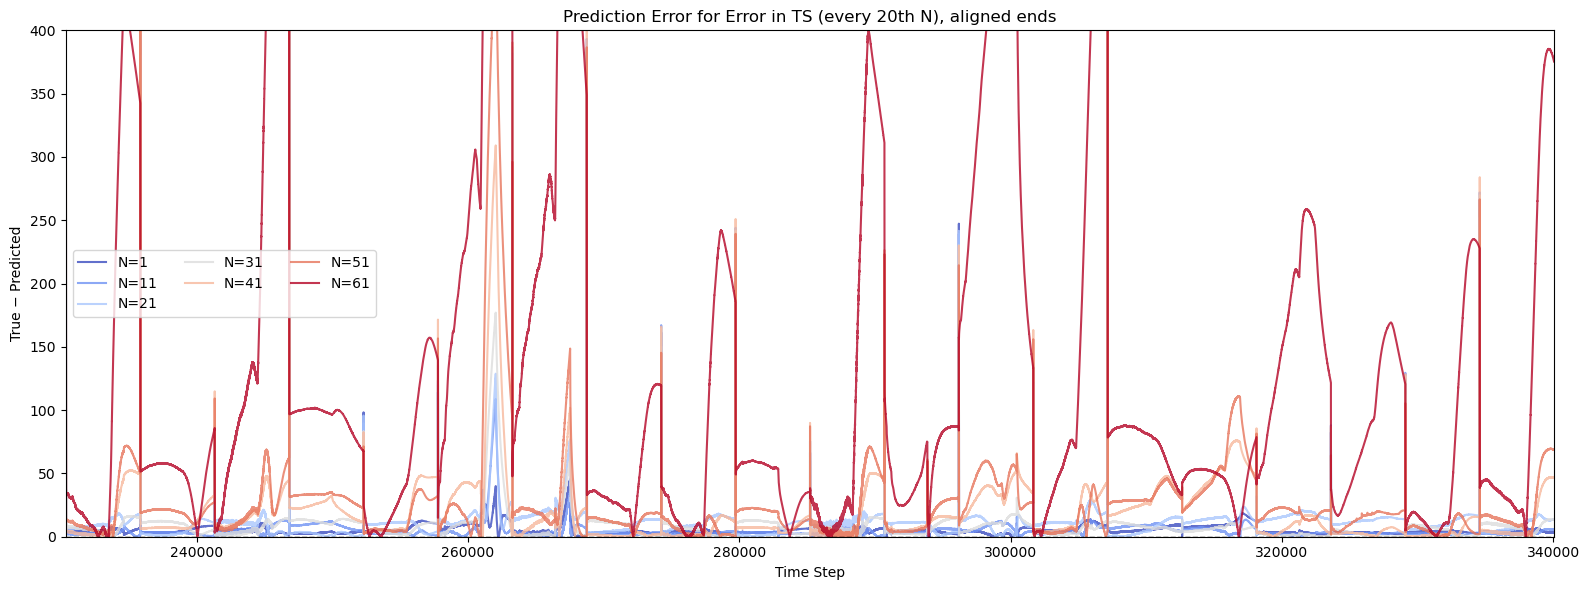

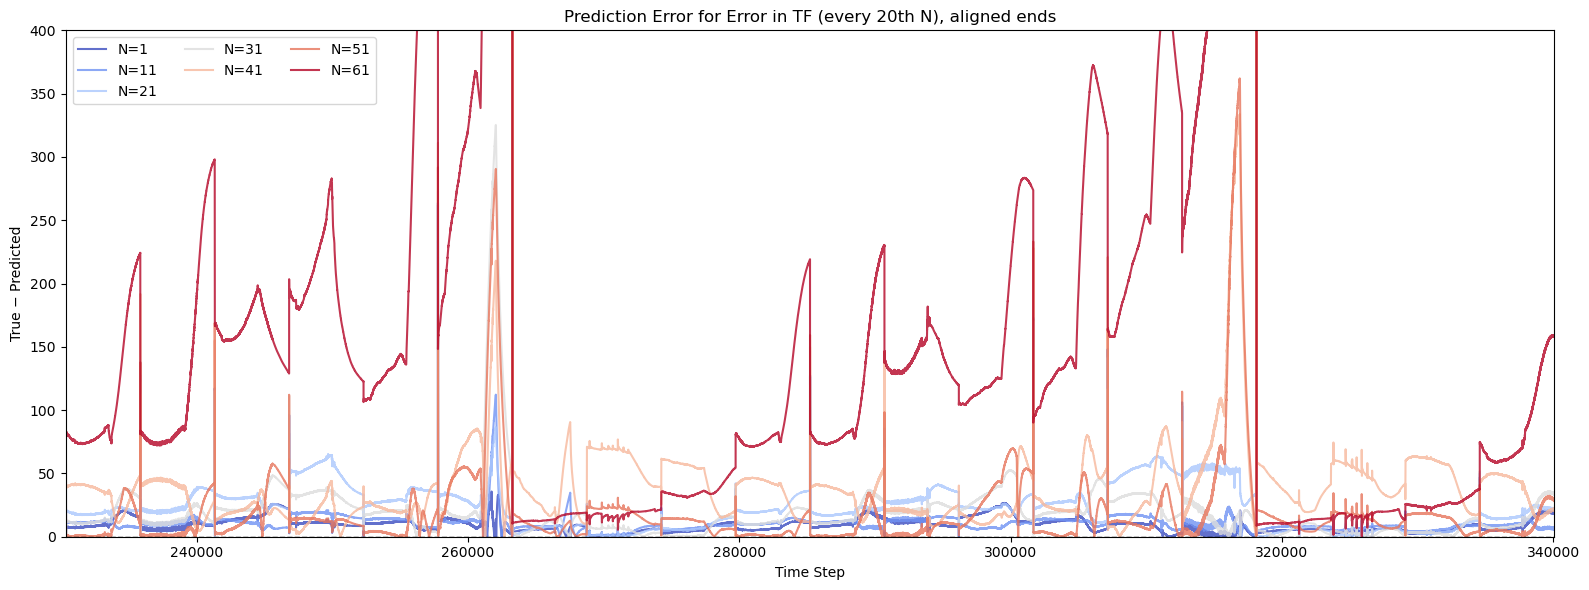

In [33]:
# # 1) Gather & sort your reallocate directories
# dirs = sorted(
#     [d for d in os.listdir('.') if os.path.isdir(d) and d.startswith('reallocate_')],
#     key=lambda x: int(x.split('_')[1])
# )

# # 2) Load all runs
# runs = []
# for d in dirs:
#     N = int(d.split('_')[1])
#     tfile = os.path.join(d, 'Ytrue_rescaled.npy')
#     pfile = os.path.join(d, 'Ypred_rescaled.npy')
#     if os.path.exists(tfile) and os.path.exists(pfile):
#         Ytrue = np.load(tfile)
#         Ypred = np.load(pfile)
#         runs.append((N, Ytrue, Ypred))

# 3) Sample every 20th run (or change the interval)
sampled = runs[::10]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# 4) Fixed x-axis endpoint
x_end = 340070

# 5) Prepare colormap from blue → red
cmap = cm.get_cmap('coolwarm', len(sampled))

# 6) Plot error (true - pred) separately for each output
for out_idx in [0, 1]:
    plt.figure(figsize=(16, 6))

    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = len(Ypred)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # compute error: true minus predicted
        error = np.abs(Ytrue[:, out_idx] - Ypred[:, out_idx])

        # plot error curve
        plt.plot(x_vals, error,
                 color=cmap(i), alpha=0.8,
                 label=f"N={N}")

    # zero line
    plt.axhline(0, color='black', linewidth=1, linestyle='--')

    plt.xlabel('Time Step')
    ylabel = 'Error in TS' if out_idx == 0 else 'Error in TF'
    plt.ylabel('True − Predicted')
    plt.title(f'Prediction Error for {ylabel} (every 20th N), aligned ends')
    plt.legend(ncol=3)
    plt.xlim(x_end - 20*5485, x_end)
    plt.ylim(0,400)
    #plt.yscale('log')
    plt.tight_layout()
    plt.show()